# Problem 1.3

## Part (a)

Generate $n=100$ observations from the autoregression
$$
x_t=-.9x_{t-2} + w_t
$$
with $\sigma_w=1$, using the method described in Example 1.10. Next, apply the moving average filter
$$
v_t = (x_t + x_{t-1} + x_{t-2} + x_{t-3}) / 4
$$
to $x_t$, the data you generated. Now plot $x_t$ as a line and superimpose $v_t$ as a dashed line. Comment on the behaviour of $x_t$ and how applying the moving average filter changes the behavior.

Hints: Use `v = filter(x, rep(1/4, 4), sides = 1)` for the filter and note that the R code in Example 1.11 may be of help on how to add lines to existing plots.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate white noise, 50 extra to remove later like in example 1.10
w = np.random.normal(0, 1, 150)

# Autoregressive coefficient
phi = -0.9

# Generate the autoregressive series
n = len(w)
x = np.zeros(n)

# Initialize the first few values so the loop can smoothly begin
x[0] = w[0]
x[1] = w[1] - phi * x[0]

for t in range(2, n):
  x[t] = -phi * x[t-2] + w[t]

# Follow Example 1.10 and remove the first 50
x = x[-100:]

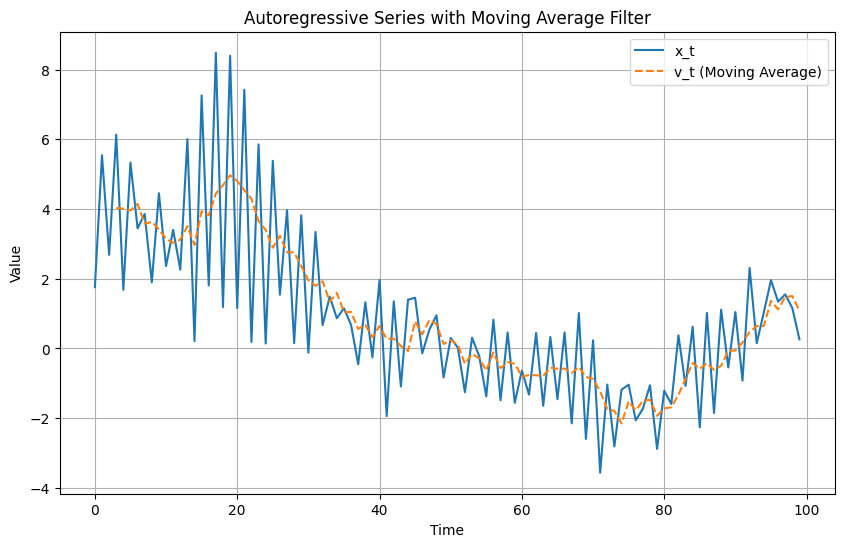

In [ ]:
def plot_autoregressive_series(x):
  # Apply the moving average filter
  filter_coeffs = np.array([1/4, 1/4, 1/4, 1/4])
  v = np.convolve(x, filter_coeffs, mode='valid')

  # Pad with Nan to line up moving average with series
  padded_v = np.pad(v, (len(x) - len(v), 0), 'constant', constant_values=np.nan)

  # Plot x_t and superimpose v_t
  plt.figure(figsize=(10, 6))
  plt.plot(x, label='x_t')
  plt.plot(padded_v, linestyle='--', label='v_t (Moving Average)')
  plt.title('Autoregressive Series with Moving Average Filter')
  plt.xlabel('Timestep')
  plt.ylabel('Value')
  plt.legend()
  plt.grid(True)
  plt.show()

# Plot Part (a)
plot_autoregressive_series(x)

## Part (b)
Repeat (a) but with
$$
x_t = cos(2\pi t/4)
$$

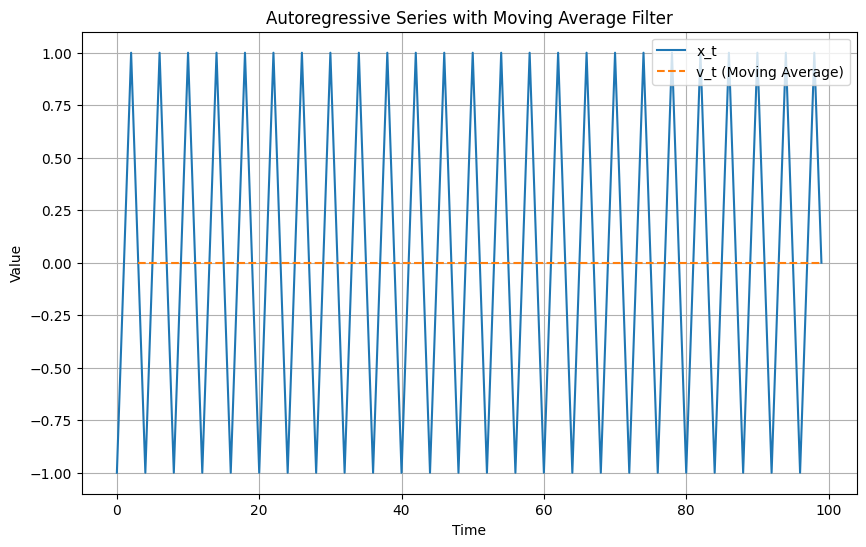

In [ ]:
# Generate white noise, 50 extra to remove later like in example 1.10
w = np.random.normal(0, 1, 150)

# Autoregressive coefficient
phi = -0.9

# Generate Autoregressive Series
n = len(w)
x = np.zeros(n)

# Initialize the first few values so the loop can smoothly begin
x[0] = w[0]
x[1] = w[1] - phi * x[0]

# Generate the new series cos(2\pi t/ 4)
for t in range(2, n):
  x[t] = np.cos(2 * np.pi * t / 4) # I guess x doesn't really use w in this one

# Follow Example 1.10 and remove the first 50
x = x[-100:]

# Plot
plot_autoregressive_series(x)

## Part (c)
Repeat (b) but with added $N(0, 1)$ noise,
$$
x_t = cos(2\pi t/4) + w_t
$$

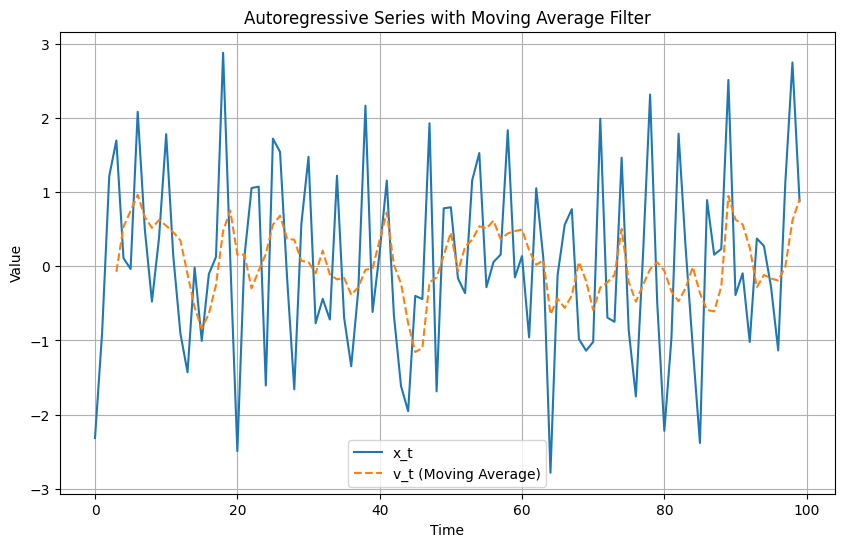

In [ ]:
# Generate white noise, 50 extra to remove later like in example 1.10
w = np.random.normal(0, 1, 150)

# Autoregressive coefficient
phi = -0.9

# Generate Autoregressive Series
n = len(w)
x = np.zeros(n)

# Initialize the first few values so the loop can smoothly begin
x[0] = w[0]
x[1] = w[1] - phi * x[0]

# Generate the new series cos(2\pi t/ 4)
for t in range(2, n):
  x[t] = np.cos(2 * np.pi * t / 4) + w[t]

# Follow Example 1.10 and remove the first 50
x = x[-100:]

# Plot
plot_autoregressive_series(x)

## Part (d)
Compare and contrast (a)-(c); i.e., how does the moving average change each series.

In (a), the moving average changes like it's following a trend even though it isn't and is similar to a random walk.

In (b), the moving average is just flat. The ups and downs are uniform since there is no white noise being added and is just a cosine wave.

In (c), the moving average fluctuates like there is an underlying signal. The moving average also smooths out the series x allowing a better look at what is being obfuscated by the white noise.

Revised: Since MA(4) has a zero at frequency 1/4, it cancels the cosine in both (b) and (c). The filtered output in (c) is smoothed noise, not a recovered cosine.

# Problem 1.4
Show that the autocovariance function can be written as
$$
\gamma(s, t)= E[(x_s - \mu_s)(x_t - \mu_t)] = E(x_s x_t) - \mu_s \mu_t
$$
Where $E[x_t] = \mu_t$.

We know
$$
E[x_t]=\mu_t\\\\
E[x_s]=\mu_s
$$

Expand
$$
E[(x_s - \mu_s)(x_t - \mu_t)]\\\\
E[x_sx_t - \mu_sx_t - \mu_tx_s + \mu_s\mu_t]
$$

Linearity of Expectation
$$
E[x_sx_t] - \mu_sE[x_t] - \mu_tE[x_s] + \mu_s\mu_t
$$

Substitute with Given
$$
E[x_sx_t] - \mu_s\mu_t - \mu_t\mu_s + \mu_s\mu_t
$$

Simplify
$$
E[x_sx_t] - \mu_s\mu_t
$$

# Math Problems

## Problem 1

Demonstrate that $cos(ix) = cosh(x)$ and $cosh(ix) = cos(x)$

Definitions:
$$
\cos(x)=\frac{e^{ix}+e^{-ix}}{2},cosh(x)=\frac{e^x+e^{-x}}{2}
$$

Start with
$$
cos(ix)\\\\
cos(ix)=\frac{e^{iix} + e^{-iix}}{2}\\\\
cos(ix)=\frac{e^x + e^{-x}}{2} = cosh(x)
$$


---


Next
$$
cosh(ix)\\\\
cosh(ix) = \frac{e^{ix} + e^{-ix}}{2} = cos(x)
$$

## Problem 2

Use the reasoning above, find the relation between $sin(ix)\ and\ sinh(x)$ and the relation between $sinh(ix)\ and\ sin(x)$

Definitions:
$$
sin(x)=\frac{e^{ix}-e^{-ix}}{2i}, sinh(x)=\frac{e^x-e^{-x}}{2}
$$

Start with
$$
sin(ix)\\\\
sin(ix)=\frac{e^{iix}-e^{-iix}}{2i}\\\\
sin(ix)=\frac{e^{-x}-e^{x}}{2i}
$$

<br>
The fraction looks similar to $sinh$ but needs some manipulation
$$
sin(ix)=\frac{e^{-x}-e^{x}}{2i}\\\\
sin(ix)=\frac{-1}{i}(\frac{-e^{-x} + e^{x}}{2})\\\\
sin(ix)=\frac{-1}{i}(sinh(x))\\\\
sin(ix)=i(sinh(x))
$$


---


Next
$$
sinh(ix)\\\\
sinh(ix)=\frac{e^{ix}-e^{-ix}}{2}
$$

Also looks similar to $sin$ and needs some manipulation
$$
sinh(ix)=\frac{e^{ix}-e^{-ix}}{2}\\\\
(\frac{i}{i})sinh(ix)=(\frac{i}{i})(\frac{e^{ix}-e^{-ix}}{2})\\\\
sinh(ix)=i(\frac{e^{ix}-e^{-ix}}{2i}) = isin(x)
$$

## Problem 3

What is the value of $\sum^{∞}_{n=0} \sin(θ)^n$ for $0 \lt θ \lt π,θ \neq \frac{\pi}{2}$

Sum of Infinite Geometric Series:
$$
\sum^{\infty}_{n=0} ar^n = \frac{a}{1-r}\\\\
$$
Given that $-1 < r < 1$

Check $sin(\theta)$ range:
$$
sin(0) = 0 \\\\
sin(\pi) = 0 \\\\
sin(\pi/2) = 1
$$
Ranges between 0 to 1 over the interval 0 to $\pi$. However, $\frac{\pi}{2}$ is explicitly mentioned in $\theta \neq \frac{\pi}{2}$, hence the Sum of Infinite Geometric Series can be used.

Plugging in for answer.
$$
\frac{1}{1-sin(\theta)}
$$